In [1]:
######################################## Problem Formulation ########################################

import os
os.chdir('/Users/gauravchoudhary/Desktop/github/VRP')

import numpy as np
import matplotlib.pyplot as plt
from parsers.vrp_parser import parse_vrp_instance, parse_vrp_solution

problem = 'A-n32-k5.vrp'
vrp_filepath = os.path.join('data/instances', problem)
sol_filepath = os.path.join('data/solutions', problem.replace('.vrp', '.sol'))

instance = parse_vrp_instance(vrp_filepath)

dimension = instance.dimension
capacity = instance.capacity
coords = instance.coords
demands = instance.demands
depot_idx = instance.depot_idx
distance_matrix = instance.distance_matrix

In [2]:
# Algorithm 1: Nearest neighbor search (greedy heuristic)

# Initialize routes and set of unvisited customers.
# Goal is to visit each customer only once, respecting capacity constraints.
# Routes are constructed by locating nearest customer at each candidate point.
routes = [] ; unvisited = set(range(0, dimension)) - {depot_idx}

# Constructing route ensemble
while len(unvisited) > 0:
    
    # Initialize route from the depot
    route = [] ; current_idx = depot_idx ; route_capacity = capacity
    
    # Second while loop instead of a direct for loop
    # because the latter would just add a single optimal node.
    while len(unvisited) > 0:
        # Set benchmark for moving along the route
        closest_idx = None ; closest_distance = np.inf
        
        # Search for optimal customer index
        for idx in unvisited:
            idx_distance = distance_matrix[current_idx][idx]
            idx_demand = demands[idx]
            if route_capacity - idx_demand >= 0:    # feasible
                if idx_distance < closest_distance: # optimal
                    closest_idx = idx
                    closest_distance = idx_distance
                    
        # Route construction
        if closest_idx is not None: 
            route.append(closest_idx)
            route_capacity = route_capacity - demands[closest_idx]
            unvisited = unvisited - {closest_idx} ; current_idx = closest_idx
        else:
            break
            # Note: By design, we only enter this block if a customer's demand > capacity.
            #       A customer with such a demand is infeasible to meet and should be excluded
            #       from the network specification itself. Entering this block is independent
            #       of the closest_distance since all distances in the distance_matrix are finite.
            
    routes.append(route)

# Total distance (cost) of routes starting and ending at the depot.
def get_route_distance(route, depot_idx, distance_matrix):
    '''Compute total distance of a route: depot -> route -> depot'''
    
    total_distance = 0; current_idx = depot_idx
    for idx in route:
        total_distance = total_distance + distance_matrix[current_idx][idx]
        current_idx = idx
    total_distance = total_distance + distance_matrix[current_idx][depot_idx]
    return total_distance

total_distance = 0
for route in routes:
    total_distance = total_distance + get_route_distance(route, depot_idx, distance_matrix)

In [3]:
# Algorithm 1.1: Refining neighbor neighbor routes via 2-opt moves.
# Motivation for 2-opt moves: Any reversal of a segment is equivalent to uncrossing edges (under euclidean distances).
def get_2opt_refinement(route, depot_idx, distance_matrix):
    '''Improve route with 2-opt moves.'''
    
    improved = True
    
    # Initialize search
    while improved:
        # By default, assume improvement is not possible on route's original distance
        improved = False
        baseline_distance = get_route_distance(route, depot_idx, distance_matrix)
        
        # Construct new routes with 2-opt moves (segment reversals) and compare distance with baseline
        for i in range(len(route)):
            for j in range(i + 2, len(route)):
                left_segment = route[ : i+1] ; reversed_segment = list(reversed(route[i+1 : j+1])) ; right_segment = route[j+1 : ]
                alt_route = left_segment + reversed_segment + right_segment
                alt_distance = get_route_distance(alt_route, depot_idx, distance_matrix)
                if alt_distance < baseline_distance:
                    route = alt_route
                    improved = True
                    break
            
            if improved:
                break
            
    return route

improved_routes = [get_2opt_refinement(route, depot_idx, distance_matrix) for route in routes]

total_improved_distance = 0
for route in improved_routes:
    total_improved_distance += get_route_distance(route, depot_idx, distance_matrix)

In [4]:
# Solution validation
def validate_solution(routes, demands, capacity, dimension, depot_idx):
    '''Check if solution is feasible.'''
    
    # Check all customers visited exactly once
    visited = set()
    for route in routes:
        visited.update(route)
    
    all_customers = set(range(dimension)) - {depot_idx}  # All except depot
    
    if visited != all_customers:
        print(f'Error: Not all customers visited. Missing: {all_customers - visited}')
        return False
    
    # Check no customer visited twice
    if len(visited) != sum(len(route) for route in routes):
        print('Error: Some customers visited multiple times')
        return False
    
    # Check capacity constraints
    for i, route in enumerate(routes):
        route_demand = sum(demands[node] for node in route)
        if route_demand > capacity:
            print(f'Error: Route {i} exceeds capacity: {route_demand} > {capacity}')
            return False
    
    print("Solution is feasible")
    return True

In [5]:
print('########## Routing under nearest neighbor search ##########')
print(f'\nNumber of routes: {len(routes)}')
print(f'\nRoutes:')
for route in sorted(routes, key = len, reverse = True):
    print(route)
print(f'\nTotal distance: {total_distance:.2f}')

print('\n\n########## Routing under nearest neighbor search + 2-opt refinement ##########')
print(f'\nNumber of routes: {len(routes)}')
print(f'\nImproved routes:')
for route in sorted(improved_routes, key = len, reverse = True):
    print(route)
print(f'\nTotal improved distance: {total_improved_distance:.2f}')

valid = validate_solution(improved_routes, demands, capacity, dimension, depot_idx)

########## Routing under nearest neighbor search ##########

Number of routes: 5

Routes:
[30, 26, 16, 12, 1, 7, 14, 29, 22, 18]
[24, 27, 20, 5, 25, 10, 8]
[13, 21, 31, 19, 17, 3, 23]
[6, 2, 28, 4, 11, 9]
[15]

Total distance: 1146.40


########## Routing under nearest neighbor search + 2-opt refinement ##########

Number of routes: 5

Improved routes:
[30, 26, 16, 12, 1, 7, 18, 22, 29, 14]
[24, 8, 10, 25, 5, 20, 27]
[13, 21, 31, 19, 17, 3, 23]
[6, 2, 28, 4, 11, 9]
[15]

Total improved distance: 1124.21
Solution is feasible


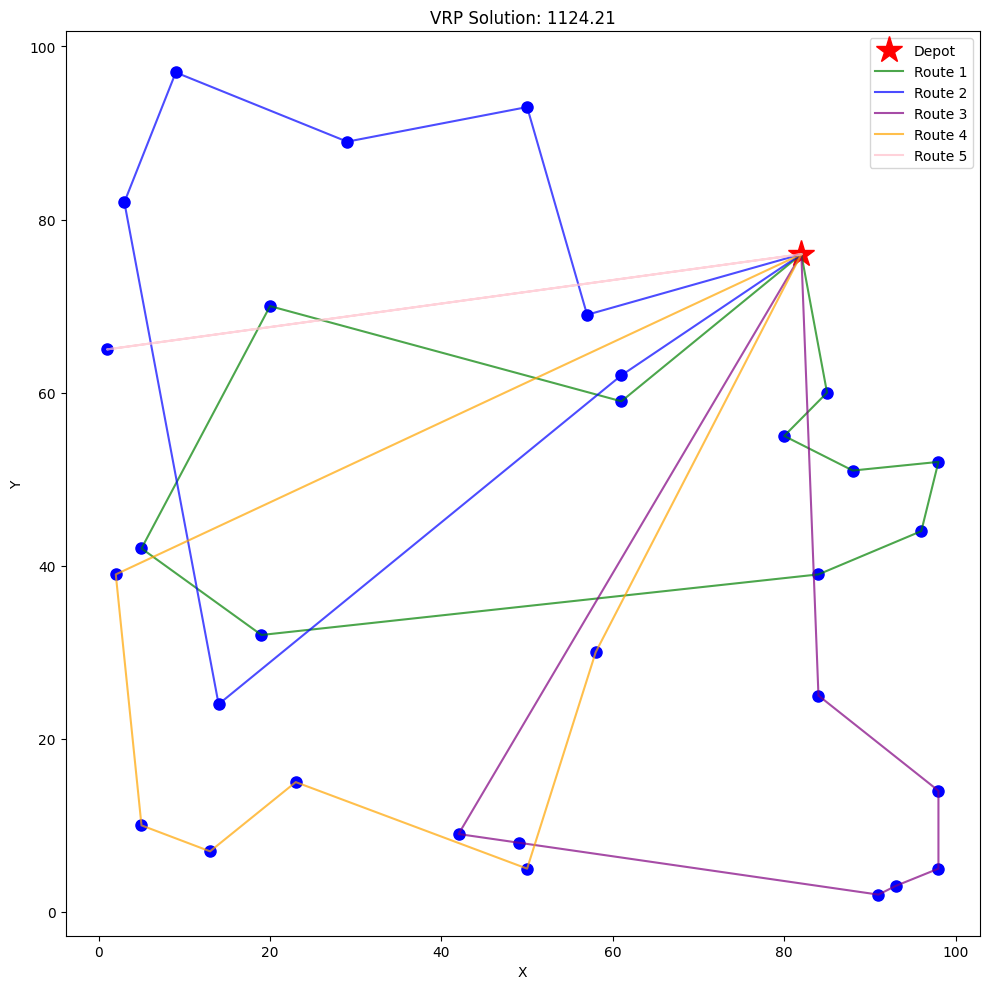

In [6]:
# Improved routes visualized

fig, ax = plt.subplots(figsize = (10, 10))
for node_id, (x, y) in coords.items():
    if node_id == depot_idx:
        ax.plot(x, y, 'r*', markersize = 20, label = 'Depot')
    else:
        ax.plot(x, y, 'bo', markersize = 8)

# Plot routes in different colors
colors = ['green', 'blue', 'purple', 'orange', 'pink']
for route_idx, route in enumerate(improved_routes):
    color = colors[route_idx % len(colors)]
    
    # Depot -> route -> depot
    nodes_in_path = [depot_idx] + route + [depot_idx]
    x_coords = [coords[node][0] for node in nodes_in_path]
    y_coords = [coords[node][1] for node in nodes_in_path]
    
    ax.plot(x_coords, y_coords, color = color, linewidth = 1.5, alpha = 0.7, label = f'Route {route_idx+1}')

ax.legend()
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title(f'VRP Solution: {total_improved_distance:.2f}')
plt.tight_layout()
plt.show()